# Experiment 6 — Left MCA terminal blockage surrogate

## Goal

This experiment simulates a **left MCA terminal blockage / high-resistance outflow lesion**.

The question is:

> What happens to left MCA regional perfusion when the distal MCA territory becomes difficult to perfuse?

This notebook modifies the `R_art` of `L-MCA_bed`. That means it represents a **distal resistance/terminal blockage surrogate**, not a detailed thrombus inside the 1D `L-MCA` vessel.

## Cases

| Case | `L-MCA_bed` arteriolar resistance multiplier |
|---|---:|
| `normal` | 1 |
| `LMCA_Rart_x2` | 2 |
| `LMCA_Rart_x5` | 5 |
| `LMCA_Rart_x20` | 20 |
| `LMCA_Rart_x100` | 100 |

## Limitation

Without leptomeningeal collateral beds, this model cannot yet show realistic pial collateral recruitment from ACA/PCA territories into the MCA territory. This experiment is still useful as a clean terminal-perfusion failure test.

In [1]:
from __future__ import annotations

import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hemo1d as hd

MMHG_TO_DYN_CM2 = 1333.22


def mmhg(value: float) -> float:
    return value * MMHG_TO_DYN_CM2


def read_config(path: Path) -> dict:
    with Path(path).open() as f:
        return json.load(f)


def write_config(config: dict, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w') as f:
        json.dump(config, f, indent=2)
    return path


def area_key(vessel: dict) -> str:
    for key in ('initial_area', 'area0', 'A0'):
        if key in vessel:
            return key
    raise KeyError('Vessel has no initial_area/area0/A0 field.')


def get_area(config: dict, vessel_id: str) -> float:
    vessel = config['vessels'][vessel_id]
    return float(vessel[area_key(vessel)])


def set_area(config: dict, vessel_id: str, area: float) -> None:
    vessel = config['vessels'][vessel_id]
    vessel[area_key(vessel)] = float(area)


def scale_area(config: dict, vessel_id: str, fraction: float) -> None:
    base_area = get_area(config, vessel_id)
    set_area(config, vessel_id, base_area * fraction)


def beta_key(vessel: dict) -> str:
    for key in ('beta_coeff', 'beta'):
        if key in vessel:
            return key
    raise KeyError('Vessel has no beta_coeff/beta field.')


def scale_beta(config: dict, vessel_id: str, factor: float) -> None:
    vessel = config['vessels'][vessel_id]
    key = beta_key(vessel)
    vessel[key] = float(vessel[key]) * factor


def set_all_vessel_pressures(config: dict, *, p0_mmhg: float = 80.0, p_ext_mmhg: float = 0.0) -> None:
    """Set a consistent resting reference pressure for every vessel."""
    config.setdefault('defaults', {})
    config['defaults']['p0'] = mmhg(p0_mmhg)
    config['defaults']['p_ext'] = mmhg(p_ext_mmhg)

    for vessel in config['vessels'].values():
        vessel['p0'] = mmhg(p0_mmhg)
        vessel['p_ext'] = mmhg(p_ext_mmhg)


def set_capillary_venous_pressure(config: dict, p_ven_mmhg: float) -> None:
    for bed in config.get('capillary_beds', {}).values():
        bed['P_ven'] = mmhg(p_ven_mmhg)


def set_capillary_initial_pressure(config: dict, p0_mmhg: float) -> None:
    for bed in config.get('capillary_beds', {}).values():
        bed['P0'] = mmhg(p0_mmhg)


def make_pressure_inlet(mean_mmhg: float, amp1_mmhg: float, amp2_mmhg: float, *, phase_s: float = 0.0):
    """Use the source-code waveform creator, not a notebook-local redefinition."""
    return hd.create_arterial_pressure_inflow(
        mean_mmhg=mean_mmhg,
        amp1_mmhg=amp1_mmhg,
        amp2_mmhg=amp2_mmhg,
        heart_rate=1.2,
        ramp_time=0.20,
        phase_s=phase_s,
    )


def install_pressure_inlets(model) -> None:
    model.set_inlet(
        vessel_id='L-ICA_I',
        side='right',
        kind='pressure',
        function=make_pressure_inlet(85.0, 14.0, 4.0, phase_s=0.00),
    )
    model.set_inlet(
        vessel_id='R-ICA_I',
        side='right',
        kind='pressure',
        function=make_pressure_inlet(85.0, 14.0, 4.0, phase_s=0.00),
    )
    model.set_inlet(
        vessel_id='BAS',
        side='left',
        kind='pressure',
        function=make_pressure_inlet(84.0, 11.0, 3.0, phase_s=0.04),
    )


def add_mid_probes(model, vessel_ids: tuple[str, ...]) -> None:
    for vessel_id in vessel_ids:
        if vessel_id not in model.config.vessels:
            continue
        length = model.config.vessel(vessel_id).length
        model.add_probe(vessel_id=vessel_id, position=0.5 * length, name='mid')


def configure_model(config_path: Path, *, probe_vessels: tuple[str, ...], method: str = 'CG'):
    model = hd.load_from_config(config_path)
    install_pressure_inlets(model)
    model.set_solver(
        method=method,
        h=0.0625,
        dt=1.0e-5,
        poly_order=1,
        dg_time_scheme='rk2',
        record_every=10,
    )
    add_mid_probes(model, probe_vessels)
    return model


def late_mask(times: np.ndarray, fraction: float = 0.25) -> np.ndarray:
    tail_start = times[-1] - fraction * (times[-1] - times[0])
    return times >= tail_start


def bed_late_means(results, bed_id: str) -> dict[str, float]:
    samples = results.capillary_bed_history(bed_id)
    times = np.array([s.time for s in samples])
    tail = late_mask(times)

    pcap_mmhg = np.array([s.pressure for s in samples]) / MMHG_TO_DYN_CM2
    inflow_ml_min = np.array([s.total_inflow for s in samples]) * 60.0
    venous_ml_min = np.array([s.venous_outflow for s in samples]) * 60.0
    perfusion = np.array([s.regional_perfusion for s in samples]) * 6000.0

    return {
        'Pcap [mmHg]': float(np.mean(pcap_mmhg[tail])),
        'Flow [mL/min]': float(np.mean(inflow_ml_min[tail])),
        'Venous out [mL/min]': float(np.mean(venous_ml_min[tail])),
        'Perfusion [mL/100g/min]': float(np.mean(perfusion[tail])),
        'Pcap min [mmHg]': float(np.min(pcap_mmhg[tail])),
        'Pcap max [mmHg]': float(np.max(pcap_mmhg[tail])),
    }


def summarize_beds(results, *, case: str) -> pd.DataFrame:
    rows = []
    for bed_id in results.capillary_bed_ids():
        row = {'case': case, 'bed': bed_id}
        row.update(bed_late_means(results, bed_id))
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['case', 'bed'])


def probe_late_mean_flow(results, vessel_id: str, probe_name: str = 'mid') -> float | None:
    samples = results.history.probes.by_vessel_and_name(vessel_id, probe_name)
    if not samples:
        return None
    times = np.array([s.time for s in samples])
    tail = late_mask(times)
    q_ml_min = np.array([s.flow_rate for s in samples]) * 60.0
    return float(np.mean(q_ml_min[tail]))


def summarize_probe_flows(results, *, case: str, vessels: tuple[str, ...]) -> pd.DataFrame:
    rows = []
    for vessel_id in vessels:
        q = probe_late_mean_flow(results, vessel_id)
        if q is not None:
            rows.append({'case': case, 'vessel': vessel_id, 'mid flow [mL/min]': q})
    return pd.DataFrame(rows)


def plot_metric(summary: pd.DataFrame, *, x: str, y: str, hue: str | None = None, title: str = '') -> None:
    plt.figure(figsize=(8, 4.5))
    if hue is None:
        for bed, group in summary.groupby('bed'):
            plt.plot(group[x], group[y], marker='o', label=bed)
    else:
        for name, group in summary.groupby(hue):
            plt.plot(group[x], group[y], marker='o', label=str(name))
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [2]:
BASE_CONFIG_PATH = Path('./configs/CoW_normal.json')
GENERATED_CONFIG_DIR = Path('./configs/generated_notebooks/mca_blockage')
OUTPUT_ROOT = Path('./outputs/notebooks/06_mca_blockage')
T_END = 2.0
RUN_SIMULATIONS = True

RART_MULTIPLIERS = {
    'normal': 1.0,
    'LMCA_Rart_x2': 2.0,
    'LMCA_Rart_x5': 5.0,
    'LMCA_Rart_x20': 20.0,
    'LMCA_Rart_x100': 100.0,
}

PROBE_VESSELS = (
    'L-MCA', 'R-MCA', 'L-ICA_I', 'R-ICA_I',
    'L-ACA_II', 'R-ACA_II', 'L-PCA_II', 'R-PCA_II',
    'ACA', 'L-PCommA', 'R-PCommA',
)

In [3]:
def scale_bed_r_art(config: dict, bed_id: str, multiplier: float) -> None:
    bed = config['capillary_beds'][bed_id]
    for outlet in bed['outlets']:
        outlet['R_art'] = float(outlet['R_art']) * multiplier


def make_mca_blockage_config(case_name: str, rart_multiplier: float) -> Path:
    config = read_config(BASE_CONFIG_PATH)
    config = copy.deepcopy(config)
    set_all_vessel_pressures(config, p0_mmhg=80.0, p_ext_mmhg=0.0)
    set_capillary_initial_pressure(config, 35.0)
    set_capillary_venous_pressure(config, 8.0)

    scale_bed_r_art(config, 'L-MCA_bed', rart_multiplier)

    path = GENERATED_CONFIG_DIR / f'CoW_{case_name}.json'
    return write_config(config, path)


def run_case(case_name: str, rart_multiplier: float):
    config_path = make_mca_blockage_config(case_name, rart_multiplier)
    model = configure_model(config_path, probe_vessels=PROBE_VESSELS)
    results = model.solve(t_end=T_END, show_progress=True, progress_description=case_name)

    output_dir = OUTPUT_ROOT / case_name
    results.save(output_dir)
    results.plot_capillary_beds(output_dir / 'plots', show=False)
    return results

In [4]:
all_beds = []
all_flows = []

if RUN_SIMULATIONS:
    for case_name, multiplier in RART_MULTIPLIERS.items():
        results = run_case(case_name, multiplier)
        beds = summarize_beds(results, case=case_name)
        beds['L-MCA R_art multiplier'] = multiplier
        all_beds.append(beds)

        flows = summarize_probe_flows(results, case=case_name, vessels=PROBE_VESSELS)
        flows['L-MCA R_art multiplier'] = multiplier
        all_flows.append(flows)

    bed_summary = pd.concat(all_beds, ignore_index=True)
    flow_summary = pd.concat(all_flows, ignore_index=True)
else:
    for case_name, multiplier in RART_MULTIPLIERS.items():
        make_mca_blockage_config(case_name, multiplier)
    bed_summary = pd.DataFrame()
    flow_summary = pd.DataFrame()

bed_summary

normal: 0%|          | 0.00000/2.00000 [00:00<?]

LMCA_Rart_x2: 0%|          | 0.00000/2.00000 [00:00<?]

LMCA_Rart_x5: 0%|          | 0.00000/2.00000 [00:00<?]

LMCA_Rart_x20: 0%|          | 0.00000/2.00000 [00:00<?]

LMCA_Rart_x100: 0%|          | 0.00000/2.00000 [00:00<?]

,case,bed,Pcap [mmHg],Flow [mL/min],Venous out [mL/min],Perfusion [mL/100g/min],Pcap min [mmHg],Pcap max [mmHg],L-MCA R_art multiplier
0,normal,L-ACA_bed,33.165199,100.481007,93.196519,50.240503,29.572020,37.667208,1.0
1,normal,L-MCA_bed,35.193249,206.141919,191.317061,54.247873,31.268359,39.979801,1.0
2,normal,L-PCA_bed,35.100024,90.949888,85.313564,53.499934,31.952641,39.283143,1.0
3,normal,R-ACA_bed,34.089427,104.208306,96.619294,52.104153,30.323025,38.765413,1.0
4,normal,R-MCA_bed,35.535562,208.906731,193.725396,54.975455,31.520337,40.431793,1.0
5,normal,R-PCA_bed,35.172270,91.191998,85.541001,53.642352,32.038171,39.386838,1.0
6,LMCA_Rart_x2,L-ACA_bed,33.163666,100.437983,93.190842,50.218992,29.587538,37.638179,2.0
7,LMCA_Rart_x2,L-MCA_bed,25.051003,128.598172,119.961682,33.841624,22.819345,27.868745,2.0
8,LMCA_Rart_x2,L-PCA_bed,35.083020,90.851193,85.260033,53.441878,31.958173,39.229161,2.0
9,LMCA_Rart_x2,R-ACA_bed,34.087854,104.183952,96.613470,52.091976,30.332449,38.748754,2.0


,case,L-MCA R_art multiplier,bed,Flow [mL/min],Perfusion [mL/100g/min],Pcap [mmHg]
0,normal,1.0,L-ACA_bed,100.481007,50.240503,33.165199
1,normal,1.0,L-MCA_bed,206.141919,54.247873,35.193249
3,normal,1.0,R-ACA_bed,104.208306,52.104153,34.089427
4,normal,1.0,R-MCA_bed,208.906731,54.975455,35.535562
6,LMCA_Rart_x2,2.0,L-ACA_bed,100.437983,50.218992,33.163666
7,LMCA_Rart_x2,2.0,L-MCA_bed,128.598172,33.841624,25.051003
9,LMCA_Rart_x2,2.0,R-ACA_bed,104.183952,52.091976,34.087854
10,LMCA_Rart_x2,2.0,R-MCA_bed,208.912212,54.976898,35.535100
12,LMCA_Rart_x5,5.0,L-ACA_bed,100.438800,50.219400,33.170282
13,LMCA_Rart_x5,5.0,L-MCA_bed,60.286263,15.864806,16.032586


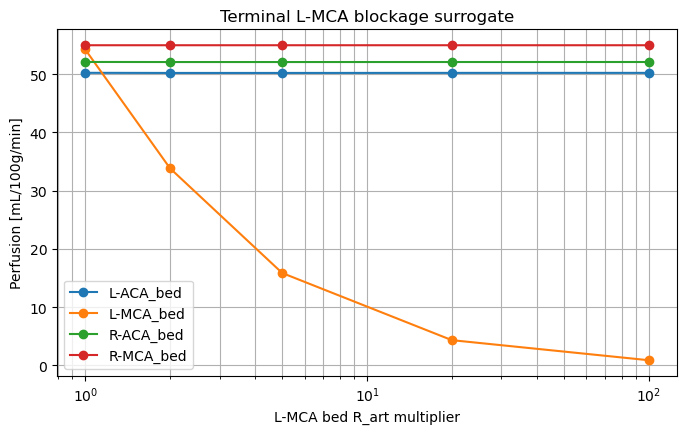

In [5]:
if RUN_SIMULATIONS:
    anterior = bed_summary[bed_summary['bed'].isin(['L-MCA_bed', 'R-MCA_bed', 'L-ACA_bed', 'R-ACA_bed'])]
    display(anterior[['case', 'L-MCA R_art multiplier', 'bed', 'Flow [mL/min]', 'Perfusion [mL/100g/min]', 'Pcap [mmHg]']])

    plt.figure(figsize=(8, 4.5))
    for bed_id, group in anterior.groupby('bed'):
        plt.semilogx(group['L-MCA R_art multiplier'], group['Perfusion [mL/100g/min]'], marker='o', label=bed_id)
    plt.xlabel('L-MCA bed R_art multiplier')
    plt.ylabel('Perfusion [mL/100g/min]')
    plt.title('Terminal L-MCA blockage surrogate')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()

## Expected result

`L-MCA_bed` perfusion should decrease monotonically as its arteriolar resistance is increased. Other beds should remain much closer to normal because this experiment does not yet add leptomeningeal collateral coupling.

A useful extension is to connect neighboring regional beds with high-resistance pial collateral links, for example `ACA ↔ MCA` and `PCA ↔ MCA`. That would turn this from a terminal blockage test into a more realistic stroke-collateral experiment.